# Customer churn

## Exploration des données

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
#Import de la source dans un dataframe
df = pd.read_excel (r'P12-Churn-Modelling.xlsx', sheet_name='Churn Modelling')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.shape

(10000, 14)

In [5]:
df.size

140000

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


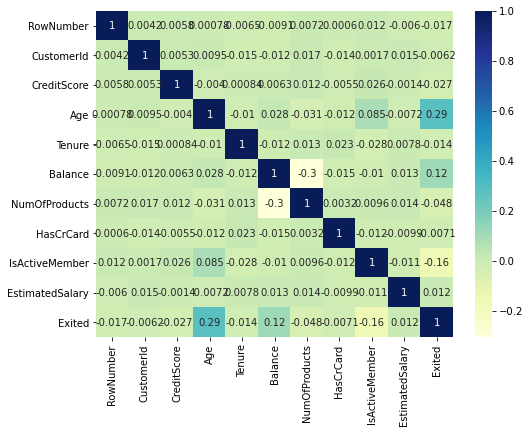

In [7]:
fig,axis = plt.subplots(figsize=(8,6))
axis = sb.heatmap(data=df.corr(method='pearson',min_periods=1),annot=True,cmap="YlGnBu")

In [8]:
# Client qui reste (=0) --- Client qui part (=1)
Nbr_Exited = df['Exited'].value_counts()
Nbr_Exited

0    7963
1    2037
Name: Exited, dtype: int64

In [9]:
df['NumOfProducts'].value_counts()

1    5084
2    4590
3     266
4      60
Name: NumOfProducts, dtype: int64

In [10]:
# Liste des valeurs des catégories (50 est une valeur arbitraire | Exclu les valeurs numériques)
categorical_col = []
print("=============================================")
for column in df.columns:
    if df[column].dtype == object and len(df[column].unique()) <= 50:
        categorical_col.append(column)
        print(f"{column} : {df[column].unique()}")
        print("=============================================")

Geography : ['France' 'Spain' 'Germany']
Gender : ['Female' 'Male']


## Preprocessing

In [11]:
# supprimer les colonnes non nécessaire à la classification
df = df.drop(['RowNumber', 'CustomerId', 'Surname','CreditScore', 'EstimatedSalary'], axis = 1)

In [12]:
df.head()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,France,Female,42,2,0.00,1,1,1,1
1,Spain,Female,41,1,83807.86,1,0,1,0
2,France,Female,42,8,159660.80,3,1,0,1
3,France,Female,39,1,0.00,2,0,0,0
4,Spain,Female,43,2,125510.82,1,1,1,0


In [13]:
df.head()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,France,Female,42,2,0.00,1,1,1,1
1,Spain,Female,41,1,83807.86,1,0,1,0
2,France,Female,42,8,159660.80,3,1,0,1
3,France,Female,39,1,0.00,2,0,0,0
4,Spain,Female,43,2,125510.82,1,1,1,0


In [14]:
# Eclater les colonnes Geography et Gender afin de manipuler des valeurs booléennes pour chaque catégorie
df = pd.get_dummies(df)
df.head()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,42,2,0.00,1,1,1,1,1,0,0,1,0
1,41,1,83807.86,1,0,1,0,0,0,1,1,0
2,42,8,159660.80,3,1,0,1,1,0,0,1,0
3,39,1,0.00,2,0,0,0,1,0,0,1,0
4,43,2,125510.82,1,1,1,0,0,0,1,1,0


Les colonnes Gender_Female/Gender_Male et Geography_France/Geography_Germany/Geography_Spain sont linéairement dépendantes. Il convient donc de supprimer les colonnes inutiles.

In [15]:
df = df.drop(['Geography_Spain', 'Gender_Male'], axis = 1)

In [16]:
df.head()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_France,Geography_Germany,Gender_Female
0,42,2,0.00,1,1,1,1,1,0,1
1,41,1,83807.86,1,0,1,0,0,0,1
2,42,8,159660.80,3,1,0,1,1,0,1
3,39,1,0.00,2,0,0,0,1,0,1
4,43,2,125510.82,1,1,1,0,0,0,1


## Apprentissage supervisé

### Scinder le dataset pour isoler la target des caractéristiques (y = target --- X = caractéristiques)

In [17]:
y = df['Exited']
X = df.drop(['Exited'], axis = 1)

In [18]:
X.head()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Gender_Female
0,42,2,0.00,1,1,1,1,0,1
1,41,1,83807.86,1,0,1,0,0,1
2,42,8,159660.80,3,1,0,1,0,1
3,39,1,0.00,2,0,0,1,0,1
4,43,2,125510.82,1,1,1,0,0,1


In [19]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

### Création des ensembles de données de test et d'entrainement

In [20]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.2, random_state = 1)

### Régression linéaire

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
# on entraine notre modèle
linReg = LinearRegression().fit(Xtrain, ytrain)
linReg

LinearRegression()

In [23]:
linScore = linReg.score(Xtest, ytest)
linScore

0.16783295960583688

In [24]:
linReg.predict(Xtest)

array([ 0.12437528,  0.18425853,  0.15363009, ..., -0.00858852,
        0.16809944,  0.34943094])

In [25]:
print(ytest)

9953    0
3850    0
4962    0
3886    0
5437    0
       ..
3919    0
162     0
7903    0
2242    0
2745    0
Name: Exited, Length: 2000, dtype: int64


### Régression logistique

In [26]:
from sklearn.linear_model import LogisticRegression
logReg = LogisticRegression().fit(Xtrain, ytrain)
logReg

LogisticRegression()

In [27]:
log_score = logReg.score(Xtest, ytest)
log_score

0.7925

### Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(criterion = 'entropy', random_state = 0).fit(Xtrain, ytrain)
tree_clf

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [29]:
tree_score = tree_clf.score(Xtest, ytest)
tree_score

0.794

In [30]:
tree_clf.predict(Xtrain)

array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

#### Optimisation des hyperparamètres

##### Méthode manuelle

In [31]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [32]:
cv = KFold(4, shuffle = True, random_state = 0)
score_splits = cross_val_score(DecisionTreeClassifier(max_depth = 5, random_state = 0), Xtrain, ytrain, cv = cv)
score_splits

array([0.859 , 0.852 , 0.8515, 0.848 ])

Variation du paramètre de la profondeur de l'arbre max_depth 1->20

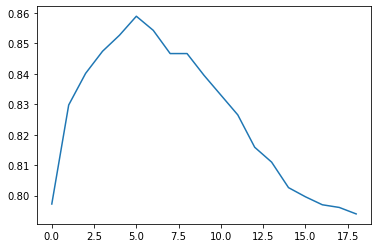

In [33]:
val_score = []
for k in range(1,20):
    score = cross_val_score(DecisionTreeClassifier(max_depth = k, random_state = 0), Xtrain, ytrain, cv = cv).mean()
    val_score.append(score)
    
plt.plot(val_score)

Observation : La précision la plus élevée est atteinte pour une valeur de max_depth = 5

##### Méthode automatique (permet d'optimiser plusieurs hyperparamètres en même temps)

In [34]:
from sklearn.model_selection import GridSearchCV
import numpy as np

In [35]:
param_grid = {'criterion': ['gini', 'entropy'],
              'max_depth': np.arange(1,20)}

grid = GridSearchCV(DecisionTreeClassifier(random_state = 0), param_grid, cv = 5)

grid.fit(Xtrain, ytrain)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [36]:
grid.best_params_

{'criterion': 'entropy', 'max_depth': 7}

In [37]:
grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=0)

In [38]:
grid.best_score_

0.8587499999999999

Evaluation du modèle de prédiction sur les données de test

In [39]:
model = grid.best_estimator_
model.score(Xtest, ytest)

0.86

Représentation de l'arbre de décision

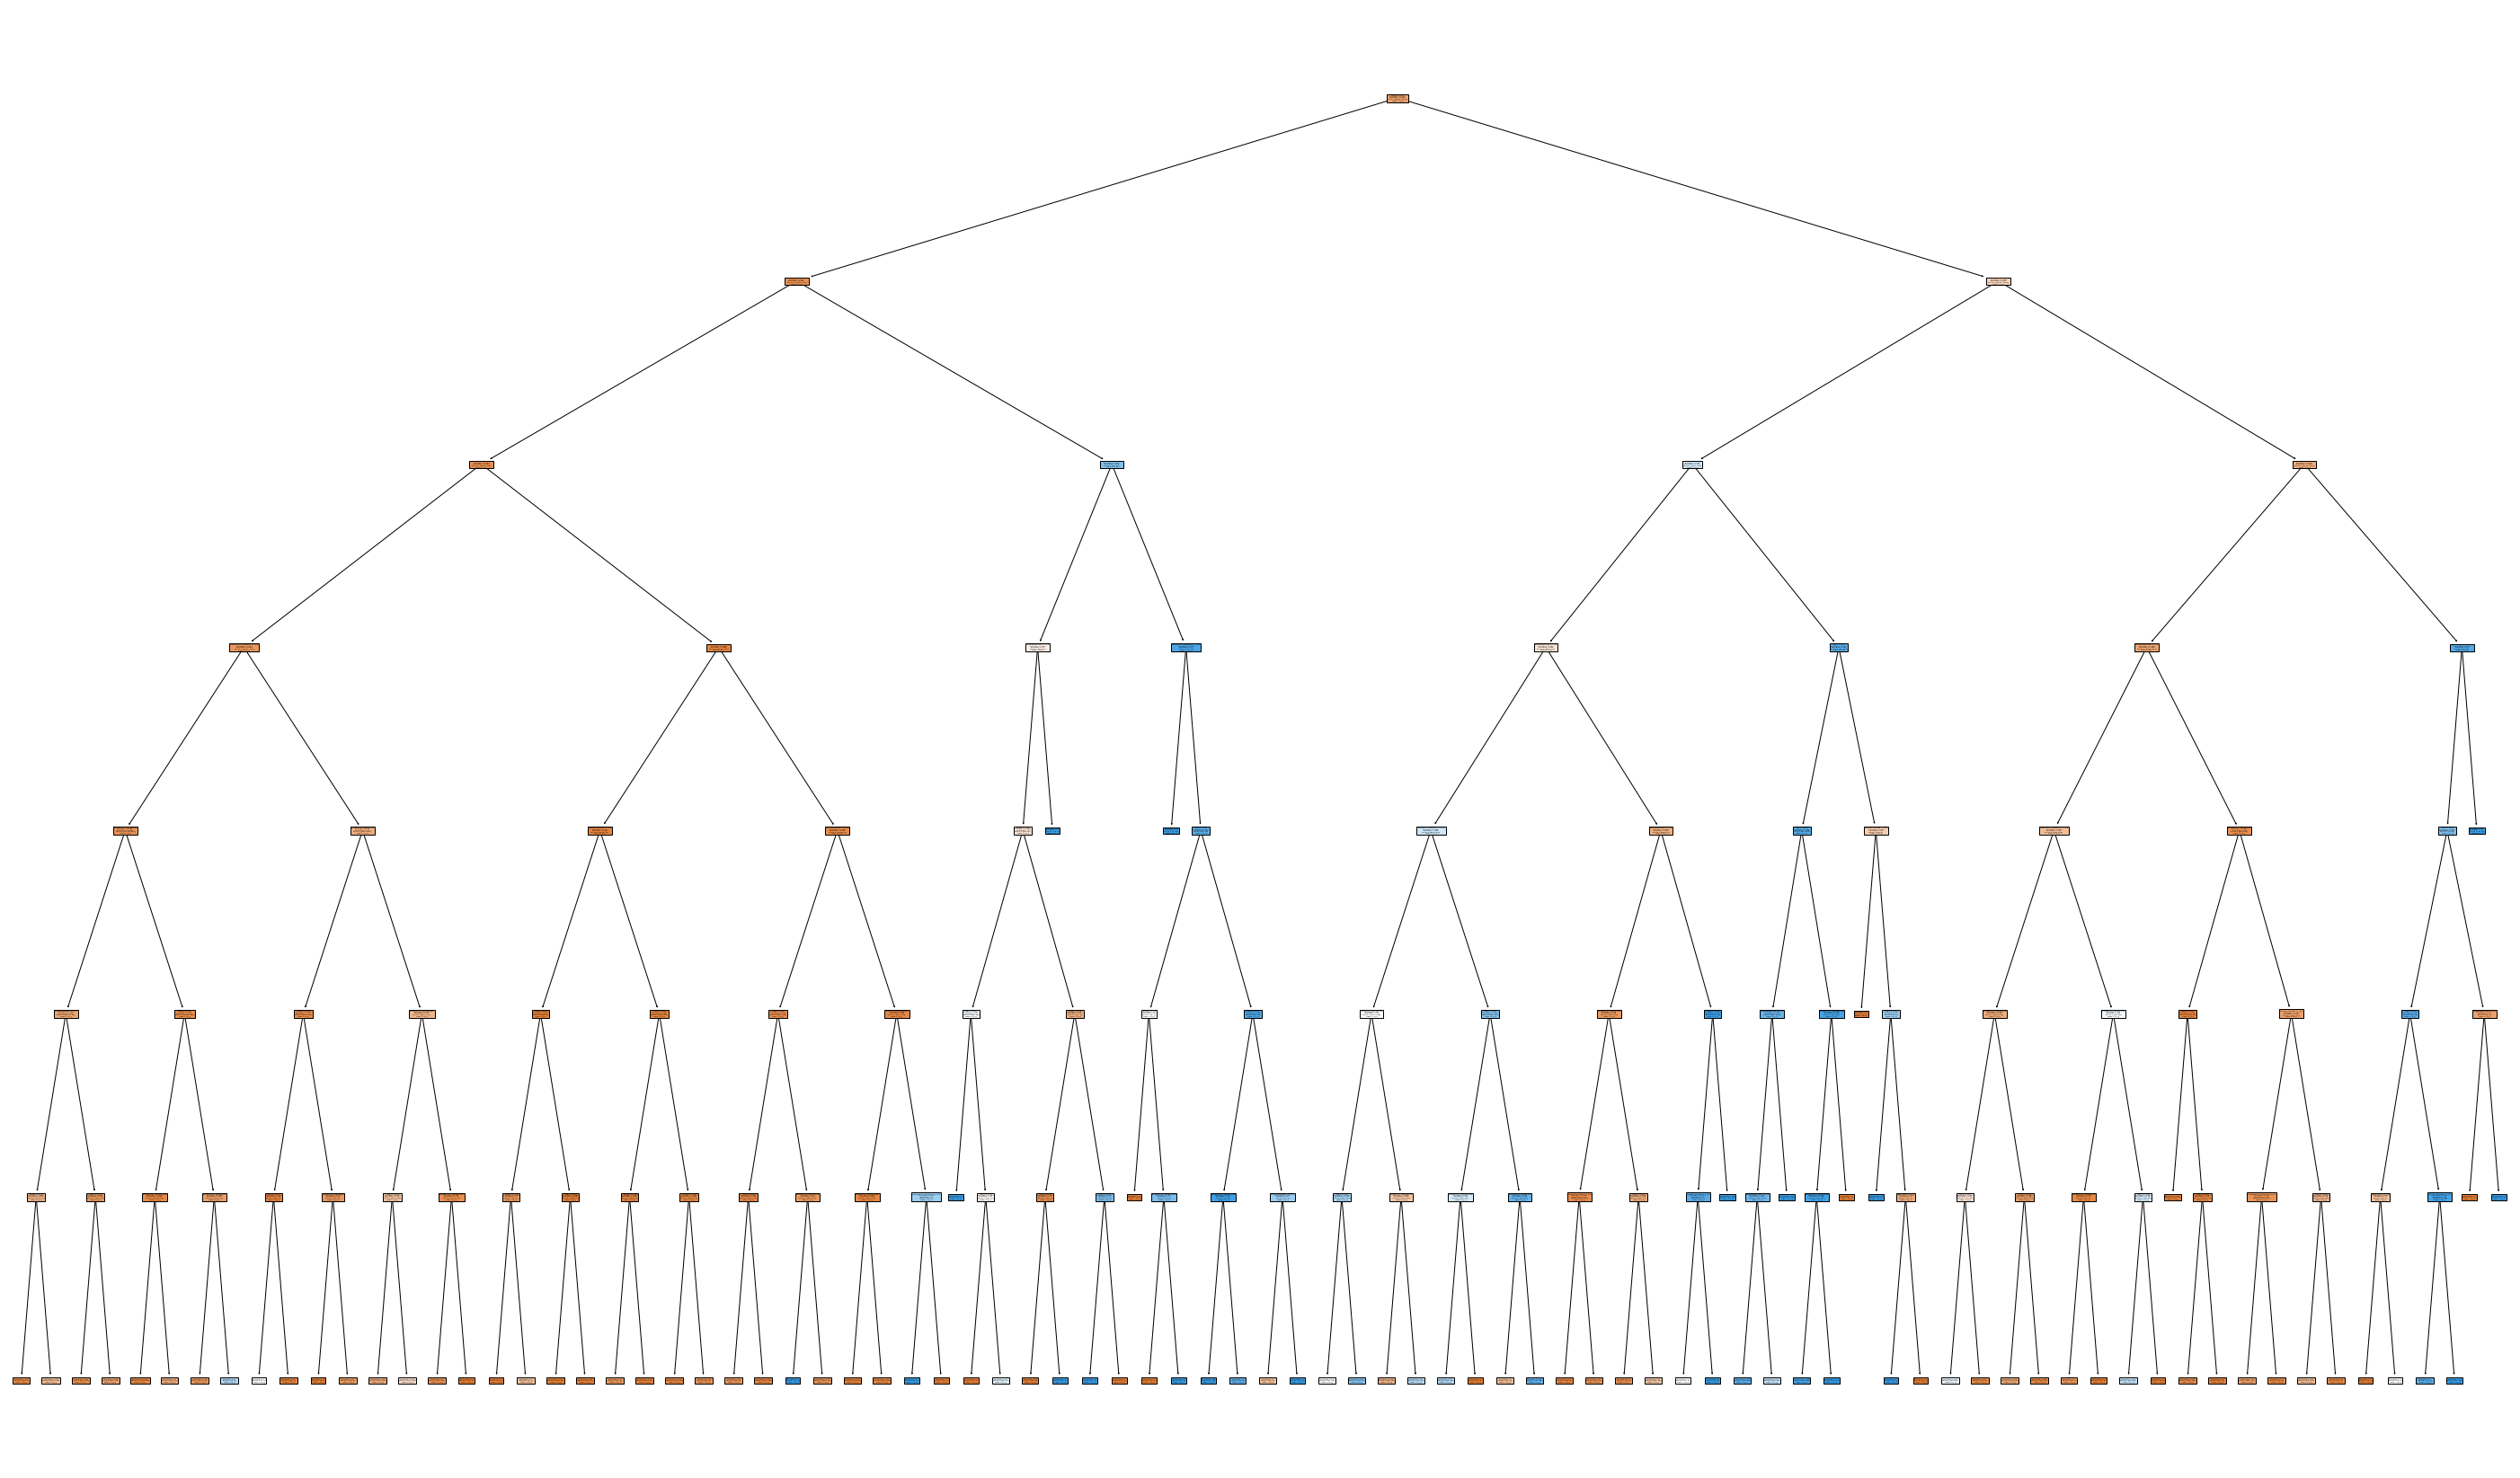

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize = (50, 30))

#affichage de l'arbre

plot_tree(model, feature_names = X.columns,class_names = True, filled = True)

plt.savefig('myTree.pdf')

plt.show()

In [41]:
yPred = model.predict(Xtest)
yPred

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, yPred)
cm

array([[1510,   75],
       [ 205,  210]], dtype=int64)

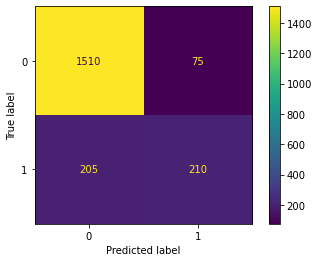

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm).plot()


### Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [45]:
classifier = RandomForestClassifier(n_estimators=200, random_state=0)  
classifier.fit(Xtrain, ytrain)  
predictions = classifier.predict(Xtest)
predictions

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

#### Mesure de l'impact d'une caractéristique sur la prédiction

In [46]:
print(classification_report(ytest,predictions ))  
print(accuracy_score(ytest, predictions ))
#Signification des indicateurs : https://towardsdatascience.com/accuracy-precision-recall-or-f1-331fb37c5cb9

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1585
           1       0.73      0.48      0.58       415

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.84      2000

0.856


<AxesSubplot:>

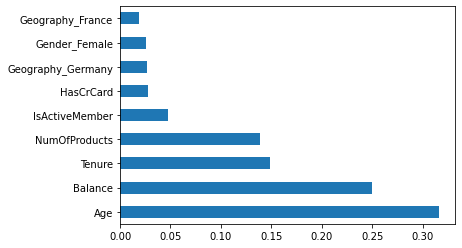

In [47]:
feat_importances = pd.Series(classifier.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')

### KNN

In [48]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np 

Optimisation des hyperparamètres

In [49]:
param_grid = {'weights': ['uniform', 'distance'],
              'n_neighbors': np.arange(1,20),
              'metric' : ['euclidean', 'manhattan', 'minkowski']}

grid_KNN = GridSearchCV(KNeighborsClassifier(), param_grid, cv = 5)

grid_KNN.fit(Xtrain, ytrain)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'weights': ['uniform', 'distance']})

In [50]:
grid_KNN.best_estimator_

KNeighborsClassifier(metric='manhattan', n_neighbors=19)

In [51]:
grid_KNN.best_params_

{'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}

In [52]:
grid_KNN.best_score_

0.803625

Evaluation avec des données de test

In [53]:
model_KNN = grid_KNN.best_estimator_
model_KNN.score(Xtest, ytest)

0.797

### Neural network

##### Installation des librairies

In [54]:
conda install pip

Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [55]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [56]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [57]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [58]:
classifier = Sequential()

Le classificateur prends le nombre de noeuds dans la couche en paramètre. Une méthode heuristique pour le définir est de prendre la moyenne des inputs et des outputs

Création de la couche d'entrée

In [59]:
classifier.add(Dense(6, activation = 'relu', input_shape = (Xtrain.shape[1], )))
classifier.add(Dropout(rate=0.1))

Création d'une autre couche cachée

In [60]:
classifier.add(Dense(6, activation = 'relu')) 
classifier.add(Dropout(rate=0.1)) 

Création d'une couche de sortie et application d'une fonction sigmoide afin d'avoir des probabilités en sortie

In [61]:
classifier.add(Dense(1, activation = 'sigmoid'))

Recap :

In [62]:
classifier.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 6)                 60        
_________________________________________________________________
dropout (Dropout)            (None, 6)                 0         
_________________________________________________________________
dense_1 (Dense)              (None, 6)                 42        
_________________________________________________________________
dropout_1 (Dropout)          (None, 6)                 0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 7         
Total params: 109
Trainable params: 109
Non-trainable params: 0
_________________________________________________________________


In [63]:
classifier.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

Fitting

In [64]:
history = classifier.fit(Xtrain, ytrain, batch_size=32, epochs=200, validation_split=0.1, verbose=2)

Epoch 1/200
225/225 - 2s - loss: 407.7578 - accuracy: 0.7231 - val_loss: 0.7077 - val_accuracy: 0.7788
Epoch 2/200
225/225 - 0s - loss: 120.7311 - accuracy: 0.7653 - val_loss: 0.5933 - val_accuracy: 0.7788
Epoch 3/200
225/225 - 0s - loss: 107.3853 - accuracy: 0.7836 - val_loss: 0.5650 - val_accuracy: 0.7788
Epoch 4/200
225/225 - 0s - loss: 83.6549 - accuracy: 0.7883 - val_loss: 0.5492 - val_accuracy: 0.7788
Epoch 5/200
225/225 - 0s - loss: 71.7776 - accuracy: 0.7896 - val_loss: 0.5382 - val_accuracy: 0.7788
Epoch 6/200
225/225 - 0s - loss: 55.0253 - accuracy: 0.7929 - val_loss: 0.5317 - val_accuracy: 0.7788
Epoch 7/200
225/225 - 0s - loss: 28.8147 - accuracy: 0.7910 - val_loss: 0.5271 - val_accuracy: 0.7788
Epoch 8/200
225/225 - 0s - loss: 21.9266 - accuracy: 0.7922 - val_loss: 0.5240 - val_accuracy: 0.7788
Epoch 9/200
225/225 - 0s - loss: 6.6188 - accuracy: 0.7951 - val_loss: 0.5206 - val_accuracy: 0.7788
Epoch 10/200
225/225 - 0s - loss: 11.0255 - accuracy: 0.7985 - val_loss: 0.5173 

#### Testing

In [65]:
ypred = classifier.predict(Xtest)
print(ypred[:5])

[[0.05955473]
 [0.23905239]
 [0.12538925]
 [0.23905239]
 [0.23905239]]


In [66]:
ypred = (ypred > 0.5).astype(int)
print(ypred[:5])

[[0]
 [0]
 [0]
 [0]
 [0]]


In [67]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, ypred)
print(cm)

[[1582    3]
 [ 403   12]]


In [68]:
print (((cm[0][0]+cm[1][1])*100)/(len(ytest)))

79.7


Ce résultat doit être considéré avec précaution. Nous pourrions réitérer cette démarche en changeant les paramètres du réseau pour évaluer le résultat.